# O objetivo desta etapa é utilizar algoritmos de aprendizado supervisionado para prever o consumo energético das construções a partir das variáveis presentes no dataset.

In [13]:
!pip install xgboost

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [15]:
# Substitua pela URL que você copiou no passo 3
url_github = "https://raw.githubusercontent.com/renanaqn/energy-weather-ml/refs/heads/main/datasets/train_energy_data.csv"

# Lendo o arquivo Excel direto da web
df = pd.read_csv(url_github)

display(df.head())

df.info()

df.describe()

df.columns

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

# Pré-processamento dos Dados

---

Nesta etapa foi realizada a preparação dos dados para o treinamento do modelo de aprendizado supervisionado. Inicialmente, a variável alvo definida foi a coluna Energy Consumption, que representa o consumo de energia a ser previsto pelo modelo. As demais colunas foram utilizadas como variáveis de entrada (X), contendo as características que ajudam na previsão do consumo energético.

Em seguida, as variáveis categóricas foram convertidas em valores numéricos utilizando a técnica get_dummies(), permitindo que o algoritmo de machine learning consiga interpretar informações textuais, como categorias de construção. O parâmetro drop_first=True foi utilizado para evitar redundância matemática entre as categorias.

Posteriormente, os dados foram divididos em conjuntos de treino e teste utilizando a função train_test_split(), onde 80% dos dados foram destinados ao treinamento do modelo e 20% à validação dos resultados. O parâetro random_state=42 garante que a divisão dos dados seja reproduzível em diferentes execuções.

Por fim, foi aplicada a padronização dos dados por meio do StandardScaler, normalizando as variáveis numéricas para que todas fiquem em escalas semelhantes. Esse processo é importante para melhorar o desempenho e a estabilidade de diversos algoritmos de aprendizado de máquina, especialmente modelos sensíveis à escala dos dados.

In [16]:
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regressão Linear
---
Nesta etapa foi implementado o modelo de Regressão Linear utilizando a biblioteca LinearRegression. Inicialmente, o modelo foi instanciado e treinado com os dados de treino (X_train e y_train), permitindo que o algoritmo aprendesse a relação entre as variáveis de entrada e o consumo energético.

Após o treinamento, o modelo realizou previsões sobre os dados de teste (X_test), gerando valores estimados para a variável alvo Energy Consumption. Essas previsões foram armazenadas na variável y_pred_lr.

Em seguida, foram calculadas métricas de avaliação para medir o desempenho do modelo. O MAE (Mean Absolute Error) mede o erro médio absoluto entre os valores reais e previstos, indicando o quanto as previsões diferem do valor verdadeiro. O MSE (Mean Squared Error) calcula o erro quadrático médio, penalizando erros maiores de forma mais intensa. Já o RMSE (Root Mean Squared Error) representa a raiz quadrada do MSE, trazendo o erro de volta para a mesma unidade da variável prevista, facilitando sua interpretação.

Também foi calculado o coeficiente de determinação R² (R2 Score), que indica o quanto o modelo consegue explicar a variabilidade dos dados. Valores mais próximos de 1 representam melhor desempenho preditivo.

Por fim, os resultados obtidos foram organizados em uma lista e convertidos em um DataFrame, facilitando a visualização e comparação posterior entre diferentes modelos de regressão utilizados no projeto.

In [17]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

resultados_regressao = []
resultados_regressao.append({
    "Modelo": "Linear Regression",
    "MAE": mae_lr,
    "MSE": mse_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
})

resultados_df = pd.DataFrame(resultados_regressao)

# Decision Tree Regressor
---
Nesta etapa foi utilizado o algoritmo Decision Tree Regressor para realizar a predição do consumo energético. Diferentemente da Regressão Linear, que busca ajustar uma relação matemática contínua entre as variáveis, a Árvore de Decisão realiza previsões por meio de divisões sucessivas nos dados, criando regras de decisão baseadas nas características das amostras.

Inicialmente, o modelo foi criado utilizando a classe DecisionTreeRegressor, sendo definido o parâmetro random_state=42 para garantir a reprodutibilidade dos resultados. Em seguida, o modelo foi treinado com os dados de treino (X_train e y_train), aprendendo padrões e regras presentes nas variáveis explicativas para estimar o consumo de energia.

Após o treinamento, o modelo realizou previsões utilizando os dados de teste (X_test), gerando os valores previstos armazenados em y_pred_dt. Para avaliar o desempenho do modelo, foram calculadas diferentes métricas estatísticas.

O MAE (Mean Absolute Error) representa o erro médio absoluto entre os valores reais e previstos. O MSE (Mean Squared Error) mede o erro quadrático médio, atribuindo penalização maior para previsões mais distantes do valor real. Já o RMSE (Root Mean Squared Error) corresponde à raiz quadrada do MSE, permitindo interpretar o erro na mesma unidade do consumo energético previsto.

Além disso, foi calculado o coeficiente de determinação R², utilizado para medir o quanto o modelo consegue explicar a variabilidade dos dados observados. Valores de R² mais próximos de 1 indicam maior capacidade preditiva.

Por fim, os resultados obtidos foram exibidos na tela e adicionados ao DataFrame de resultados, possibilitando a comparação do desempenho da Árvore de Decisão com os demais modelos de regressão aplicados no projeto.

In [18]:
modelo_dt = DecisionTreeRegressor(
    random_state=42
)

modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("===== Decision Tree =====")

print(f"MAE  : {mae_dt:.4f}")
print(f"MSE  : {mse_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"R²   : {r2_dt:.4f}")

resultados_regressao.append({
    "Modelo": "Decision Tree",
    "MAE": mae_dt,
    "MSE": mse_dt,
    "RMSE": rmse_dt,
    "R2": r2_dt
})

resultados_df = pd.DataFrame(resultados_regressao)

===== Decision Tree =====
MAE  : 173.1353
MSE  : 47609.0538
RMSE : 218.1950
R²   : 0.9415


# Random Forest Regressor
---
Nesta etapa foi aplicado o algoritmo Random Forest Regressor para a previsão do consumo energético. O Random Forest é um método baseado em múltiplas Árvores de Decisão, no qual diversas árvores são treinadas simultaneamente e suas previsões são combinadas para gerar um resultado final mais robusto e preciso.

O modelo foi configurado com o parâetro n_estimators=100, indicando que a floresta será composta por 100 árvores de decisão. O parâmetro random_state=42 foi utilizado para garantir a reprodutibilidade dos resultados obtidos.

Após a criação do modelo, foi realizado o treinamento utilizando os dados de treino (X_train e y_train). Durante esse processo, cada árvore aprende padrões diferentes presentes nos dados, contribuindo individualmente para a previsão final do modelo.

Em seguida, o modelo realizou previsões sobre os dados de teste (X_test), gerando os valores previstos armazenados em y_pred_rf. Para avaliar o desempenho do Random Forest, foram calculadas métricas estatísticas de erro e qualidade preditiva.

O MAE (Mean Absolute Error) mede o erro médio absoluto entre os valores reais e previstos. O MSE (Mean Squared Error) calcula o erro quadrático médio, penalizando com maior intensidade previsões mais distantes do valor real. Já o RMSE (Root Mean Squared Error) corresponde à raiz quadrada do MSE, permitindo interpretar o erro na mesma unidade da variável prevista.

Também foi calculado o coeficiente de determinação R², responsável por indicar o quanto o modelo consegue explicar a variabilidade dos dados observados. Valores de R² mais próximos de 1 indicam melhor desempenho do modelo.

Por fim, os resultados obtidos foram adicionados à estrutura resultados_regressao e convertidos em um DataFrame, permitindo a comparação entre o desempenho do Random Forest e os demais modelos de regressão utilizados no estudo.

In [19]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)
resultados_regressao.append({
    "Modelo": "Random Forest",
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf,
    "R2": r2_rf
})

resultados_df = pd.DataFrame(resultados_regressao)

# XGBoost Regressor
---
Nesta etapa foi utilizado o algoritmo XGBoost Regressor para realizar a previsão do consumo energético. O XGBoost é um modelo baseado em técnicas de boosting, no qual múltiplas árvores de decisão são construídas sequencialmente, de forma que cada nova árvore busca corrigir os erros cometidos pelas anteriores. Esse método é amplamente utilizado em problemas de regressão devido à sua alta capacidade preditiva e eficiência computacional.

O modelo foi configurado com n_estimators=100, indicando a utilização de 100 árvores no processo de aprendizado. O parâmetro learning_rate=0.1 controla a velocidade de aprendizado do modelo, permitindo que as correções ocorram de maneira gradual e reduzindo o risco de sobreajuste (overfitting). Já o parâmetro max_depth=6 define a profundidade máxima das árvores, controlando o nível de complexidade do modelo. O parâmetro random_state=42 foi utilizado para garantir a reprodutibilidade dos resultados.

Após a configuração, o modelo foi treinado utilizando os dados de treino (X_train e y_train), aprendendo os padrões existentes entre as variáveis explicativas e o consumo energético. Em seguida, o modelo realizou previsões sobre os dados de teste (X_test), gerando os valores previstos armazenados em y_pred_xgb.

Para avaliar o desempenho do modelo, foram calculadas métricas estatísticas de regressão. O MAE (Mean Absolute Error) mede o erro médio absoluto entre os valores reais e previstos. O MSE (Mean Squared Error) calcula o erro quadrático médio, penalizando previsões mais distantes dos valores reais. O RMSE (Root Mean Squared Error) corresponde à raiz quadrada do MSE, facilitando a interpretação do erro na mesma unidade do consumo energético.

Também foi calculado o coeficiente de determinação R², utilizado para medir o quanto o modelo consegue explicar a variabilidade dos dados observados. Valores mais próximos de 1 indicam melhor desempenho preditivo.

Por fim, os resultados obtidos foram adicionados à estrutura resultados_regressao e convertidos em um DataFrame, permitindo a comparação do desempenho do XGBoost com os demais modelos de regressão utilizados no projeto.

In [20]:
modelo_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(y_test, y_pred_xgb)
resultados_regressao.append({
    "Modelo": "XGBoost",
    "MAE": mae_xgb,
    "MSE": mse_xgb,
    "RMSE": rmse_xgb,
    "R2": r2_xgb
})

resultados_df = pd.DataFrame(resultados_regressao)

# SVM regressor
---
Nesta etapa foi aplicado o algoritmo Support Vector Regression (SVR) para realizar a previsão do consumo energético. O SVR é uma adaptação do algoritmo SVM (Support Vector Machine) para problemas de regressão, sendo utilizado para encontrar uma função capaz de representar os dados com o menor erro possível, mantendo uma boa capacidade de generalização.

O modelo foi configurado utilizando o parâetro kernel='rbf', que define o uso do kernel radial (Radial Basis Function). Esse tipo de kernel permite que o algoritmo consiga modelar relações não lineares entre as variáveis de entrada e o consumo energético, tornando o modelo mais flexível para identificar padrões complexos nos dados.

Após a configuração, o modelo foi treinado utilizando os dados de treino (X_train e y_train), aprendendo os padrões existentes entre as variáveis explicativas e a variável alvo. Em seguida, o SVR realizou previsões sobre os dados de teste (X_test), gerando os valores previstos armazenados em y_pred_svr.

Para avaliar o desempenho do modelo, foram calculadas métricas estatísticas de regressão. O MAE (Mean Absolute Error) mede o erro médio absoluto entre os valores reais e previstos. O MSE (Mean Squared Error) calcula o erro quadrático médio, penalizando com maior intensidade previsões mais distantes dos valores reais. Já o RMSE (Root Mean Squared Error) corresponde à raiz quadrada do MSE, permitindo interpretar o erro na mesma unidade da variável prevista.

Também foi calculado o coeficiente de determinação R², utilizado para medir a capacidade do modelo em explicar a variabilidade dos dados observados. Valores mais próximos de 1 indicam melhor desempenho preditivo.

Por fim, os resultados obtidos foram adicionados à estrutura resultados_regressao e convertidos em um DataFrame, permitindo a comparação do desempenho do SVR com os demais modelos de regressão utilizados no projeto.

In [21]:
modelo_svr = SVR(
    kernel='rbf'
)
modelo_svr.fit(X_train, y_train)
y_pred_svr = modelo_svr.predict(X_test)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

mse_svr = mean_squared_error(y_test, y_pred_svr)

rmse_svr = np.sqrt(mse_svr)

r2_svr = r2_score(y_test, y_pred_svr)
resultados_regressao.append({
    "Modelo": "SVR",
    "MAE": mae_svr,
    "MSE": mse_svr,
    "RMSE": rmse_svr,
    "R2": r2_svr
})

resultados_df = pd.DataFrame(resultados_regressao)

#MLP regressor
---
Nesta etapa foi utilizado o algoritmo MLP Regressor (Multi-Layer Perceptron Regressor) para realizar a previsão do consumo energético. O MLP é um modelo baseado em redes neurais artificiais, inspirado no funcionamento simplificado dos neurônios biológicos. Esse tipo de algoritmo é capaz de aprender relações complexas e não lineares entre as variáveis de entrada e a variável alvo.

O modelo foi configurado com hidden_layer_sizes=(100, 50), indicando que a rede neural possui duas camadas ocultas, sendo a primeira composta por 100 neurônios e a segunda por 50 neurônios. Essas camadas intermediárias são responsáveis por aprender padrões cada vez mais complexos presentes nos dados.

O parâmetro activation='relu' define a função de ativação utilizada nos neurônios da rede. A função ReLU (Rectified Linear Unit) é amplamente utilizada em redes neurais por sua eficiência computacional e capacidade de lidar com relações não lineares. Já o parâmetro max_iter=1000 estabelece o número máximo de iterações durante o treinamento, permitindo que o modelo tenha tempo suficiente para convergir. O parâmetro random_state=42 foi utilizado para garantir a reprodutibilidade dos resultados.

Após a configuração, o modelo foi treinado utilizando os dados de treino (X_train e y_train), aprendendo os padrões existentes entre as variáveis explicativas e o consumo energético. Em seguida, a rede neural realizou previsões sobre os dados de teste (X_test), gerando os valores previstos armazenados em y_pred_mlp.

Para avaliar o desempenho do modelo, foram calculadas métricas estatísticas de regressão. O MAE (Mean Absolute Error) mede o erro médio absoluto entre os valores reais e previstos. O MSE (Mean Squared Error) calcula o erro quadrático médio, penalizando previsões mais distantes dos valores reais. O RMSE (Root Mean Squared Error) corresponde à raiz quadrada do MSE, permitindo interpretar o erro na mesma unidade da variável prevista.

Também foi calculado o coeficiente de determinação R², utilizado para medir o quanto o modelo consegue explicar a variabilidade dos dados observados. Valores mais próximos de 1 indicam melhor desempenho preditivo.

Por fim, os resultados obtidos foram adicionados à estrutura resultados_regressao e convertidos em um DataFrame, permitindo a comparação do desempenho da rede neural com os demais modelos de regressão utilizados no projeto.

In [22]:
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    max_iter=1000,
    random_state=42
)
modelo_mlp.fit(X_train, y_train)
y_pred_mlp = modelo_mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)

rmse_mlp = np.sqrt(mse_mlp)

r2_mlp = r2_score(y_test, y_pred_mlp)
resultados_regressao.append({
    "Modelo": "MLP Regressor",
    "MAE": mae_mlp,
    "MSE": mse_mlp,
    "RMSE": rmse_mlp,
    "R2": r2_mlp
})

resultados_df = pd.DataFrame(resultados_regressao)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
resultados_df

,Modelo,MAE,MSE,RMSE,R2
0,Linear Regression,0.011412,0.000189,0.013731,1.000000
1,Decision Tree,173.135300,47609.053772,218.194990,0.941534
2,Random Forest,97.358536,15518.571661,124.573559,0.980942
3,XGBoost,75.251112,9157.120899,95.692847,0.988755
4,SVR,708.639775,761930.895095,872.886530,0.064312
5,MLP Regressor,61.702298,6337.718364,79.609788,0.992217


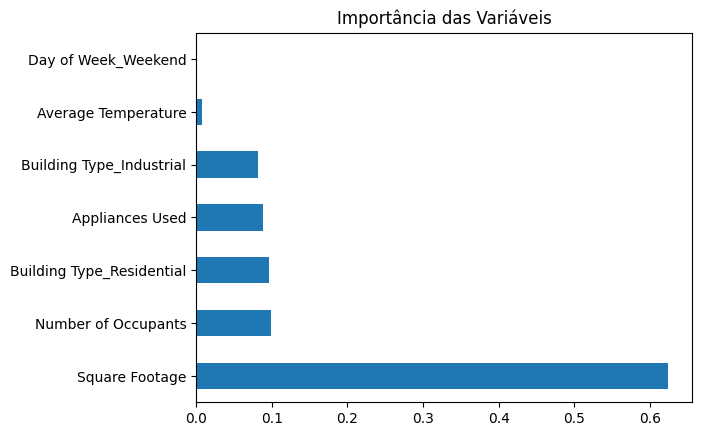

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Importância das Variáveis")
plt.show()

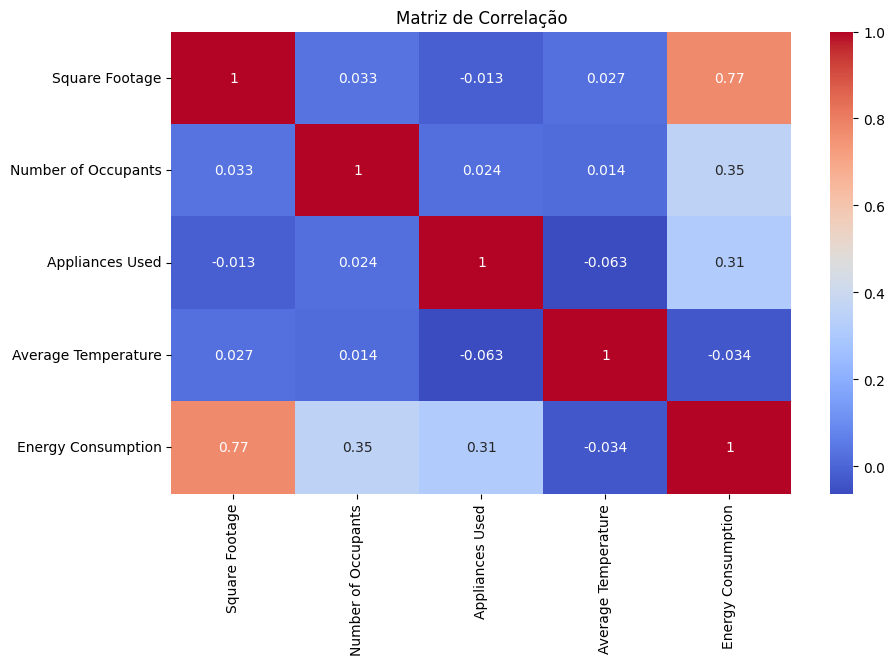

In [26]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Matriz de Correlação")
plt.show()